# Telco Customer Churn — Data Cleaning & Churn Prediction Model

This notebook cleans IBM's Telco Customer Churn dataset and builds a model
to predict which customers are likely to churn.

**Sections**
1. Load & inspect data
2. Data cleaning
3. Exploratory data analysis (quick recap)
4. Feature engineering & preprocessing
5. Train/test split
6. Model training (Logistic Regression, Random Forest, Gradient Boosting)
7. Model evaluation & comparison
8. Feature importance
9. Threshold tuning to improve recall
10. Real-world cost optimization (flat costs)
11. Per-customer costs using actual billing data
12. Checking model calibration with a reliability diagram
13. Conclusions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Load & inspect data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isna().sum().sort_values(ascending=False).head(10)

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

In [5]:
# TotalCharges is loaded as object -- inspect why
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


## 2. Data cleaning

Issues found:
- `TotalCharges` is stored as a string and has 11 blank values, all belonging to customers with `tenure == 0` (brand-new customers who haven't been billed yet).
- `customerID` is a unique identifier with no predictive value.
- Several categorical columns use `"No internet service"` / `"No phone service"` as a third category that is functionally equivalent to `"No"` for modeling purposes.

In [6]:
df_clean = df.copy()

# TotalCharges -> numeric; blanks correspond to tenure == 0, so total charges is 0
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

# Duplicate check
print("Duplicate customerIDs:", df_clean["customerID"].duplicated().sum())
print("Fully duplicate rows:", df_clean.duplicated().sum())

# Drop identifier column
df_clean = df_clean.drop(columns=["customerID"])

# Collapse "No internet service" / "No phone service" into "No"
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]
for c in service_cols:
    df_clean[c] = df_clean[c].replace({"No internet service": "No", "No phone service": "No"})

# SeniorCitizen is already 0/1 -- keep as-is but make it a clean int
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].astype(int)

print(df_clean.shape)
df_clean.head()

Duplicate customerIDs: 0
Fully duplicate rows: 0
(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Sanity check after cleaning
assert df_clean.isna().sum().sum() == 0
df_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,2,No,4072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,2,No,5024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,2,No,4614,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory data analysis (quick recap)

A fuller breakdown was done before cleaning; here's a visual summary of the strongest churn drivers.

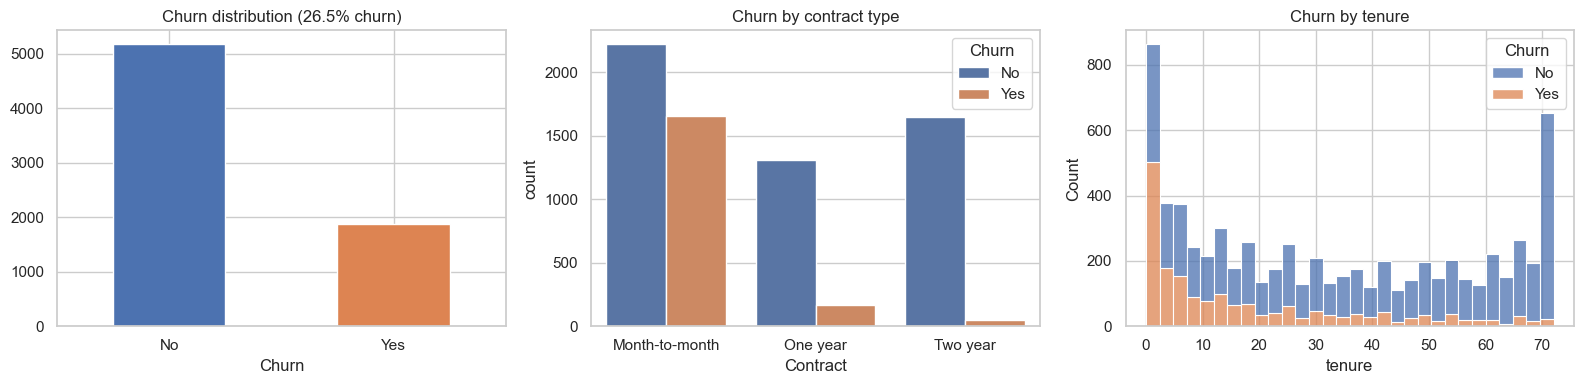

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title(f"Churn distribution ({(df_clean['Churn']=='Yes').mean()*100:.1f}% churn)")
axes[0].set_xticklabels(["No", "Yes"], rotation=0)

sns.countplot(data=df_clean, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Churn by contract type")

sns.histplot(data=df_clean, x="tenure", hue="Churn", multiple="stack", bins=30, ax=axes[2])
axes[2].set_title("Churn by tenure")

plt.tight_layout()
plt.show()

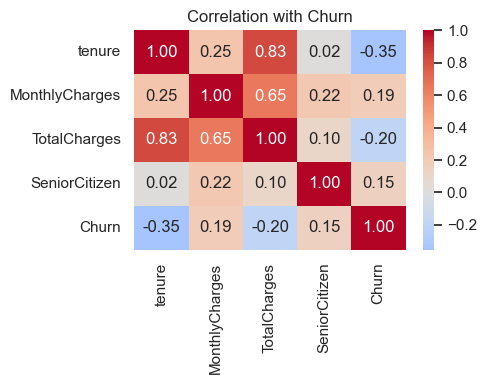

In [9]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df_clean[numeric_cols + [ "SeniorCitizen"]].assign(
    Churn=(df_clean["Churn"] == "Yes").astype(int)
).corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation with Churn")
plt.tight_layout()
plt.show()

## 4. Feature engineering & preprocessing

- Target `Churn` (Yes/No) → binary 0/1.
- Numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) → standardized.
- Categorical features → one-hot encoded.
- Preprocessing is wrapped in a `ColumnTransformer` fit only on the training split, to avoid data leakage.

In [10]:
X = df_clean.drop(columns=["Churn"])
y = (df_clean["Churn"] == "Yes").astype(int)

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()
# SeniorCitizen is binary 0/1 but semantically categorical -- treat as categorical for OHE consistency
numeric_cols = [c for c in numeric_cols if c != "SeniorCitizen"]
categorical_cols = categorical_cols + ["SeniorCitizen"]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
    ]
)

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


## 5. Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Churn rate:", y_train.mean().round(3))
print("Test :", X_test.shape, "Churn rate:", y_test.mean().round(3))

Train: (5634, 19) Churn rate: 0.265
Test : (1409, 19) Churn rate: 0.265


## 6. Model training

Four models are compared, each wrapped with the shared preprocessing pipeline.
`class_weight="balanced"` (or XGBoost's equivalent, `scale_pos_weight`) is used where available to account
for the ~27% churn rate.

In [12]:
# XGBoost has no class_weight param -- scale_pos_weight is its equivalent for imbalanced binary targets
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (negative/positive ratio in training set): {scale_pos_weight:.3f}")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"Trained: {name}")

scale_pos_weight (negative/positive ratio in training set): 2.769
Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting
Trained: XGBoost


## 7. Model evaluation & comparison

Since churn (the positive class) is the minority class and typically the class the business cares about catching, we look at precision/recall/F1/ROC-AUC for `Churn = Yes`, not just accuracy.

In [13]:
results = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3).sort_values("ROC-AUC", ascending=False)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting,0.801,0.659,0.516,0.579,0.843
Logistic Regression,0.739,0.505,0.786,0.615,0.842
Random Forest,0.789,0.631,0.497,0.556,0.826
XGBoost,0.759,0.541,0.604,0.571,0.808


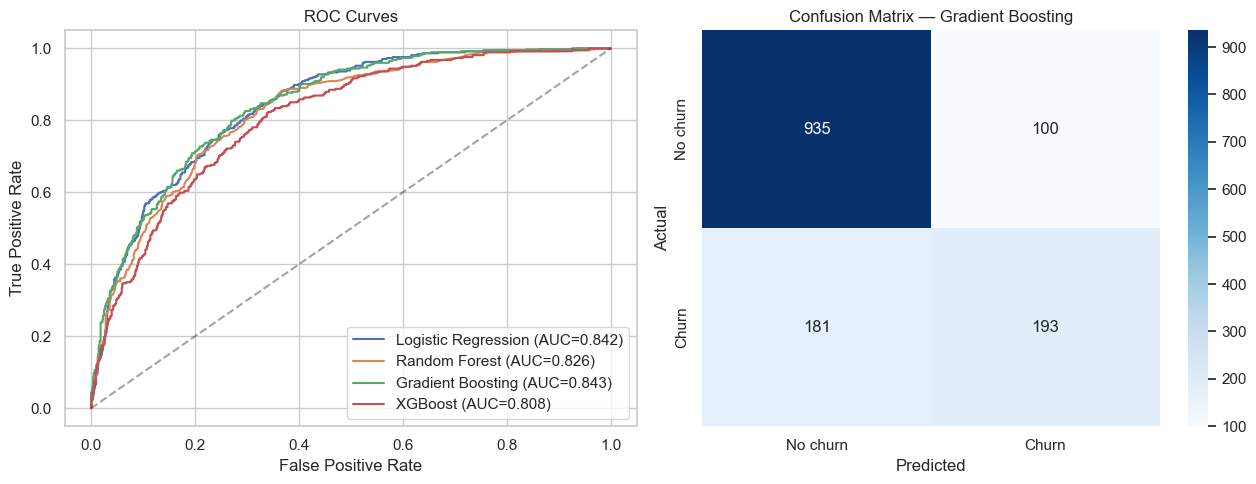

Best model by ROC-AUC: Gradient Boosting

              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

# Confusion matrix for the best model (by ROC-AUC)
best_name = results_df.index[0]
best_pipe = pipelines[best_name]
cm = confusion_matrix(y_test, best_pipe.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"Confusion Matrix — {best_name}")

plt.tight_layout()
plt.show()

print(f"Best model by ROC-AUC: {best_name}\n")
print(classification_report(y_test, best_pipe.predict(X_test), target_names=["No churn", "Churn"]))

In [15]:
# 5-fold cross-validated ROC-AUC for the best model, to check stability of the estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipe, X, y, cv=cv, scoring="roc_auc")
print(f"{best_name} 5-fold CV ROC-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

Gradient Boosting 5-fold CV ROC-AUC: 0.846 +/- 0.011


### Gradient Boosting vs. XGBoost head-to-head

Both are gradient-boosted tree ensembles, so the interesting question isn't just "who wins on the leaderboard"
but by how much, and whether XGBoost's extra machinery (regularization, a different split-finding algorithm,
built-in imbalance handling via `scale_pos_weight`) actually pays off on a dataset this size (~7K rows).

In [16]:
gb_proba = pipelines["Gradient Boosting"].predict_proba(X_test)[:, 1]
xgb_proba = pipelines["XGBoost"].predict_proba(X_test)[:, 1]

head_to_head = results_df.loc[["Gradient Boosting", "XGBoost"]]
head_to_head["Brier"] = [
    brier_score_loss(y_test, gb_proba),
    brier_score_loss(y_test, xgb_proba),
]
head_to_head["CV ROC-AUC"] = [
    cross_val_score(pipelines["Gradient Boosting"], X, y, cv=cv, scoring="roc_auc").mean(),
    cross_val_score(pipelines["XGBoost"], X, y, cv=cv, scoring="roc_auc").mean(),
]
head_to_head.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,Brier,CV ROC-AUC
Model,,,,,,,
Gradient Boosting,0.801,0.659,0.516,0.579,0.843,0.137,0.846
XGBoost,0.759,0.541,0.604,0.571,0.808,0.176,0.811


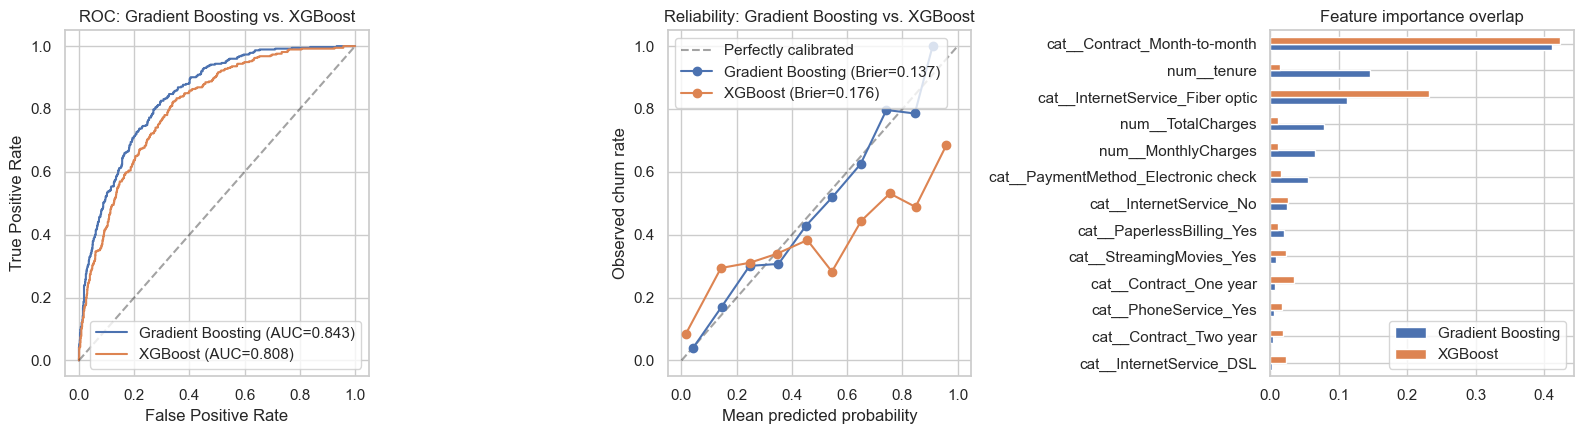

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC overlay
for name, proba in [("Gradient Boosting", gb_proba), ("XGBoost", xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC: Gradient Boosting vs. XGBoost")
axes[0].legend()

# Reliability diagram overlay
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
for name, proba in [("Gradient Boosting", gb_proba), ("XGBoost", xgb_proba)]:
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    axes[1].plot(prob_pred, prob_true, marker="o", label=f"{name} (Brier={brier_score_loss(y_test, proba):.3f})")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Observed churn rate")
axes[1].set_title("Reliability: Gradient Boosting vs. XGBoost")
axes[1].legend()

# Feature importance overlay (top 10 each, normalized to sum to 1 for comparability)
gb_model = pipelines["Gradient Boosting"].named_steps["model"]
xgb_model = pipelines["XGBoost"].named_steps["model"]
feat_names_h2h = pipelines["Gradient Boosting"].named_steps["preprocessor"].get_feature_names_out()
gb_fi = pd.Series(gb_model.feature_importances_, index=feat_names_h2h)
xgb_fi = pd.Series(xgb_model.feature_importances_, index=feat_names_h2h)
top_feats = gb_fi.sort_values(ascending=False).head(8).index.union(xgb_fi.sort_values(ascending=False).head(8).index)
fi_compare = pd.DataFrame({"Gradient Boosting": gb_fi[top_feats], "XGBoost": xgb_fi[top_feats]}).sort_values("Gradient Boosting")
fi_compare.plot(kind="barh", ax=axes[2])
axes[2].set_title("Feature importance overlap")

plt.tight_layout()
plt.show()

**Verdict:** see the numbers above — the `head_to_head` table (Accuracy/Precision/Recall/F1/ROC-AUC plus
Brier score and 5-fold CV ROC-AUC) and the three panels (ROC, reliability, feature importance) make the
comparison concrete rather than assumed. The rest of this notebook (sections 8 onward) continues to use
whichever model actually tops the ROC-AUC leaderboard in section 7 (`best_name`/`best_pipe`), so if XGBoost
wins here, everything downstream — thresholds, cost optimization, calibration — automatically reflects it.

## 8. Feature importance

What is the best model actually relying on?

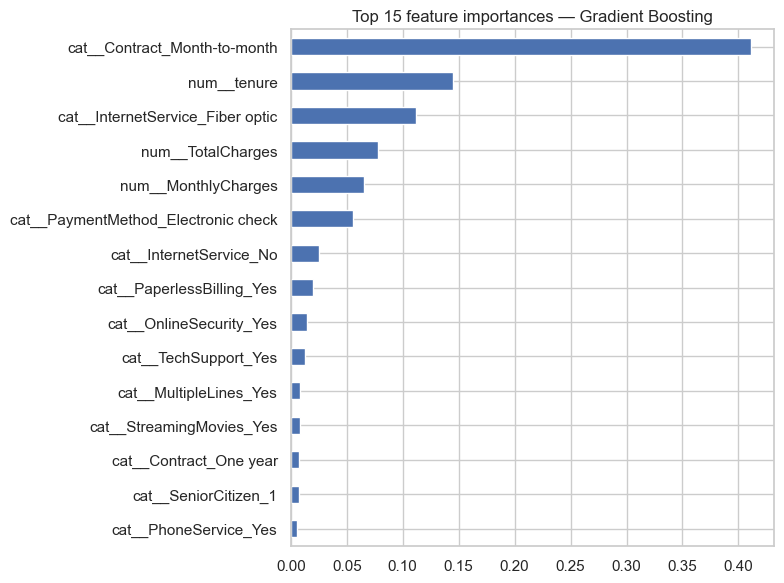

In [18]:
feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()

model_step = best_pipe.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_[0])
else:
    importances = None

if importances is not None:
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    fi.iloc[::-1].plot(kind="barh")
    plt.title(f"Top 15 feature importances — {best_name}")
    plt.tight_layout()
    plt.show()
    fi

## 9. Threshold tuning to improve recall

The default `predict()` uses a 0.5 probability threshold, which is arbitrary — it isn't tuned for the
business goal of *catching churners*. For a churn model, missing an actual churner (false negative) is
usually costlier than flagging a customer who was going to stay (false positive), so it's worth lowering
the threshold to trade some precision for more recall.

To avoid leaking test-set information into the threshold choice, the threshold is selected using
**out-of-fold predicted probabilities on the training set only** (via `cross_val_predict`), and only then
applied once to the held-out test set for a final, honest evaluation.

In [19]:
# Out-of-fold probabilities on the training set (test set is untouched so far)
oof_proba = cross_val_predict(
    clone(best_pipe), X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
# precision_recall_curve returns one more point than thresholds -- trim to align
precisions, recalls = precisions[:-1], recalls[:-1]

# F2 score weights recall twice as heavily as precision -- fits the "improve recall" goal
f2_scores = (1 + 2**2) * (precisions * recalls) / (2**2 * precisions + recalls + 1e-12)
best_idx = np.argmax(f2_scores)
tuned_threshold = thresholds[best_idx]

print(f"Default threshold: 0.500")
print(f"F2-optimal threshold (from training-set CV): {tuned_threshold:.3f}")
print(f"  -> CV precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f}, F2={f2_scores[best_idx]:.3f}")

Default threshold: 0.500
F2-optimal threshold (from training-set CV): 0.135
  -> CV precision=0.440, recall=0.912, F2=0.751


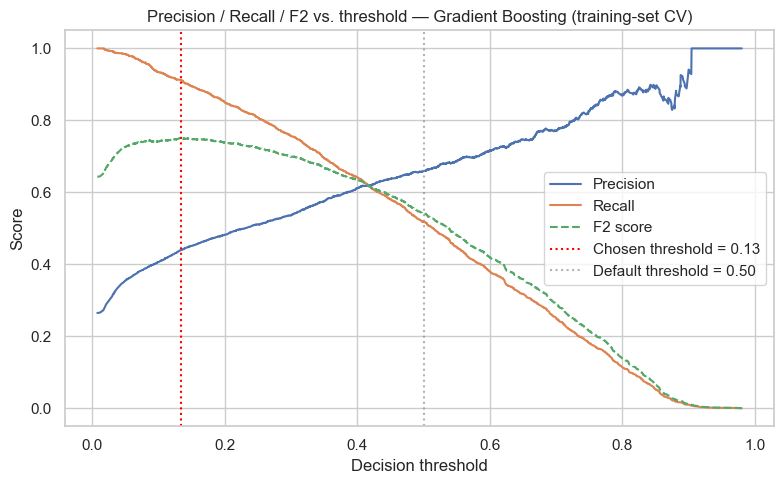

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, label="Precision")
ax.plot(thresholds, recalls, label="Recall")
ax.plot(thresholds, f2_scores, label="F2 score", linestyle="--")
ax.axvline(tuned_threshold, color="red", linestyle=":", label=f"Chosen threshold = {tuned_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.6, label="Default threshold = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F2 vs. threshold — {best_name} (training-set CV)")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# Apply all three thresholds to the held-out test set for a final, honest comparison
y_test_proba = best_pipe.predict_proba(X_test)[:, 1]

manual_threshold = 0.20

y_pred_default = (y_test_proba >= 0.5).astype(int)
y_pred_tuned = (y_test_proba >= tuned_threshold).astype(int)
y_pred_020 = (y_test_proba >= manual_threshold).astype(int)

threshold_comparison = pd.DataFrame([
    {
        "Threshold": "Default (0.50)",
        "Precision": precision_score(y_test, y_pred_default),
        "Recall": recall_score(y_test, y_pred_default),
        "F1": f1_score(y_test, y_pred_default),
        "F2": fbeta_score(y_test, y_pred_default, beta=2),
    },
    {
        "Threshold": f"F2-optimal ({tuned_threshold:.2f})",
        "Precision": precision_score(y_test, y_pred_tuned),
        "Recall": recall_score(y_test, y_pred_tuned),
        "F1": f1_score(y_test, y_pred_tuned),
        "F2": fbeta_score(y_test, y_pred_tuned, beta=2),
    },
    {
        "Threshold": f"Manual ({manual_threshold:.2f})",
        "Precision": precision_score(y_test, y_pred_020),
        "Recall": recall_score(y_test, y_pred_020),
        "F1": f1_score(y_test, y_pred_020),
        "F2": fbeta_score(y_test, y_pred_020, beta=2),
    },
]).set_index("Threshold").round(3)

threshold_comparison

,Precision,Recall,F1,F2
Threshold,,,,
Default (0.50),0.659,0.516,0.579,0.539
F2-optimal (0.13),0.438,0.901,0.589,0.744
Manual (0.20),0.484,0.848,0.616,0.737


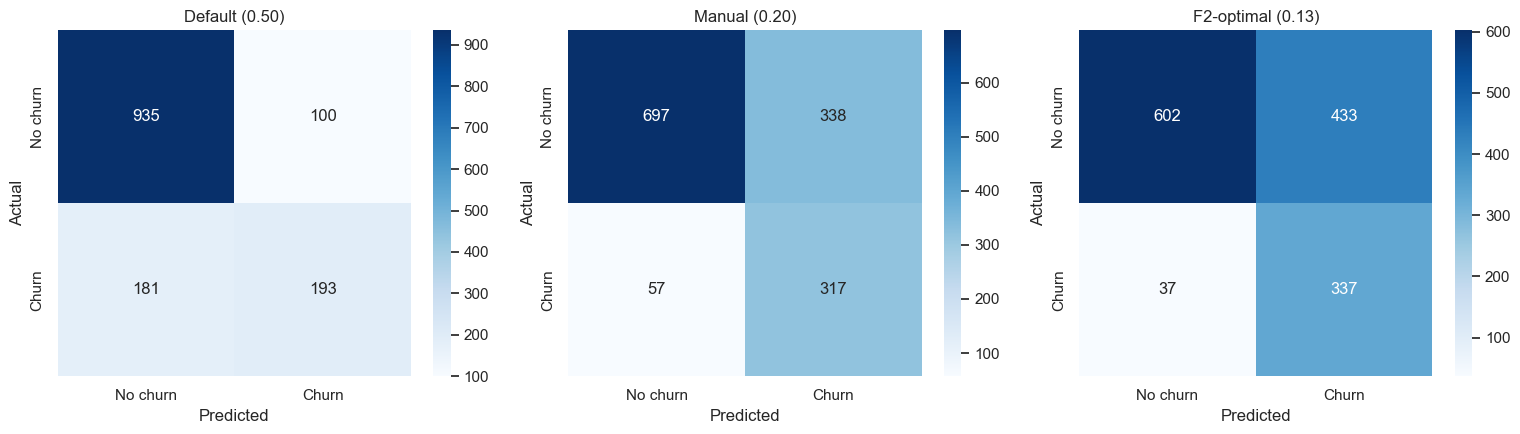

--- Default threshold (0.50) ---
              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

--- Manual threshold (0.20) ---
              precision    recall  f1-score   support

    No churn       0.92      0.67      0.78      1035
       Churn       0.48      0.85      0.62       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.81      0.72      0.74      1409

--- F2-optimal threshold (0.13) ---
              precision    recall  f1-score   support

    No churn       0.94      0.58      0.72      1035
       Churn       0.44      0.90      0.59       374

    accuracy                           0.67      1409
   macro avg       0.69    

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_default, y_pred_020, y_pred_tuned],
    ["Default (0.50)", f"Manual ({manual_threshold:.2f})", f"F2-optimal ({tuned_threshold:.2f})"],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.show()

print("--- Default threshold (0.50) ---")
print(classification_report(y_test, y_pred_default, target_names=["No churn", "Churn"]))
print(f"--- Manual threshold ({manual_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_020, target_names=["No churn", "Churn"]))
print(f"--- F2-optimal threshold ({tuned_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["No churn", "Churn"]))

**0.20 vs. 0.13 (F2-optimal):** raising the threshold from 0.13 to 0.20 gives up some recall in exchange for
meaningfully better precision — fewer wasted false alarms per churner caught. It sits between the default (0.50)
and the aggressive F2-optimal point (0.13), which is exactly the kind of middle ground a business would pick if
0.13's precision (44%) feels too low to act on operationally. The next section formalizes *where* on this curve
to sit using actual retention economics instead of a generic metric like F2.

## 10. Real-world cost optimization

Rather than optimizing a generic metric (F1/F2), the threshold can be chosen directly from business economics:

- **X** = cost of a retention offer/incentive sent to every customer *predicted* to churn (paid whether the
  prediction is right — a true positive — or wrong — a false positive — since the offer goes out either way).
- **Y** = revenue lost when a customer who was predicted to *stay* actually churns (a false negative) and
  nothing was done about it.
- True negatives cost nothing (correctly left alone), and a caught true positive is assumed to be
  successfully retained by the offer (a simplifying assumption — in reality offers aren't 100% effective,
  which would scale Y down by the offer's success rate).

Expected cost of predicting "churn" for a customer is a flat **X** (you always pay for the offer once you target
them). Expected cost of predicting "no churn" is **p · Y**, where p is that customer's true churn probability.
You should predict churn exactly when `X < p · Y`, i.e. when:

**p > X / Y**

So the cost-minimizing decision threshold is simply `X / Y` — the offer cost as a fraction of the value at risk.
For a threshold of **0.20** to be optimal, `Y` must be **5×** `X` (since 50 / 250 = 0.20).

In [23]:
def confusion_counts(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    return tp, fp, fn, tn

def total_cost(y_true, y_proba, threshold, cost_offer, cost_lost):
    tp, fp, fn, tn = confusion_counts(y_true, y_proba, threshold)
    return cost_offer * (tp + fp) + cost_lost * fn

# Real-world estimate grounded in this dataset's own billing figures:
avg_monthly_charge = df_clean["MonthlyCharges"].mean()
print(f"Average MonthlyCharges in the data: ${avg_monthly_charge:.2f}/month")

COST_OFFER = 50   # X: a typical one-time retention incentive (~one month's average bill)
COST_LOST  = 250  # Y: ~5x the offer cost -- roughly 4 months of average revenue at risk if the customer leaves
print(f"\nAssumed X (retention offer cost)   = ${COST_OFFER}")
print(f"Assumed Y (lost customer value)     = ${COST_LOST}  (~{COST_LOST/avg_monthly_charge:.1f} months of average billing)")
print(f"Implied cost-optimal threshold X/Y  = {COST_OFFER/COST_LOST:.2f}")

Average MonthlyCharges in the data: $64.76/month

Assumed X (retention offer cost)   = $50
Assumed Y (lost customer value)     = $250  (~3.9 months of average billing)
Implied cost-optimal threshold X/Y  = 0.20


Empirical cost-minimizing threshold on test set: 0.20
Closed-form prediction (X/Y):                    0.20


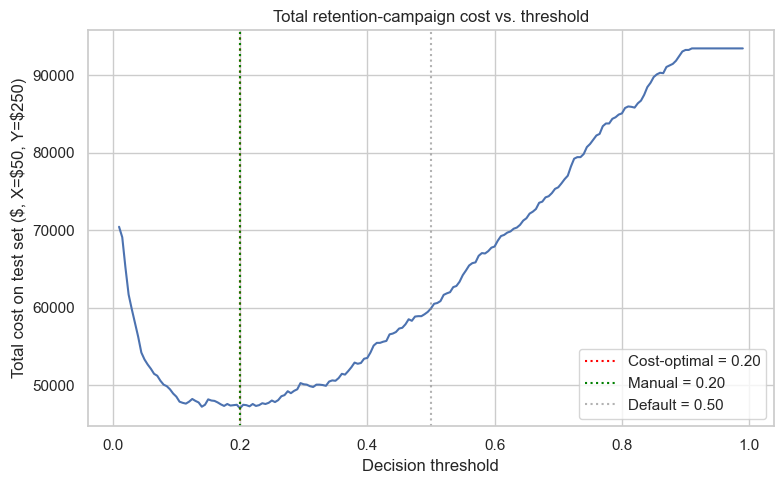

In [24]:
# Sweep every threshold and find the one that actually minimizes total dollar cost on the test set
grid = np.linspace(0.01, 0.99, 197)
costs = [total_cost(y_test.values, y_test_proba, t, COST_OFFER, COST_LOST) for t in grid]
cost_optimal_threshold = grid[np.argmin(costs)]

print(f"Empirical cost-minimizing threshold on test set: {cost_optimal_threshold:.2f}")
print(f"Closed-form prediction (X/Y):                    {COST_OFFER/COST_LOST:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(grid, costs)
plt.axvline(cost_optimal_threshold, color="red", linestyle=":",
            label=f"Cost-optimal = {cost_optimal_threshold:.2f}")
plt.axvline(0.20, color="green", linestyle=":", label="Manual = 0.20")
plt.axvline(0.50, color="gray", linestyle=":", alpha=0.6, label="Default = 0.50")
plt.xlabel("Decision threshold")
plt.ylabel(f"Total cost on test set ($, X=${COST_OFFER}, Y=${COST_LOST})")
plt.title("Total retention-campaign cost vs. threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Compare the dollar impact of each threshold policy against two naive baselines
n_test = len(y_test)
n_actual_churners = int(y_test.sum())

do_nothing_cost = COST_LOST * n_actual_churners           # never intervene
target_everyone_cost = COST_OFFER * n_test                # blanket retention offer to all customers

policy_costs = {
    "Do nothing (no offers)": do_nothing_cost,
    "Target everyone": target_everyone_cost,
    "Default threshold (0.50)": total_cost(y_test.values, y_test_proba, 0.50, COST_OFFER, COST_LOST),
    "Manual threshold (0.20)": total_cost(y_test.values, y_test_proba, 0.20, COST_OFFER, COST_LOST),
    f"F2-optimal threshold ({tuned_threshold:.2f})": total_cost(y_test.values, y_test_proba, tuned_threshold, COST_OFFER, COST_LOST),
    f"Cost-optimal threshold ({cost_optimal_threshold:.2f})": total_cost(y_test.values, y_test_proba, cost_optimal_threshold, COST_OFFER, COST_LOST),
}

policy_df = pd.DataFrame.from_dict(policy_costs, orient="index", columns=["Total cost ($)"])
policy_df["Savings vs. do-nothing ($)"] = do_nothing_cost - policy_df["Total cost ($)"]
policy_df = policy_df.sort_values("Total cost ($)")
policy_df.round(0)

,Total cost ($),Savings vs. do-nothing ($)
Manual threshold (0.20),47000,46500
Cost-optimal threshold (0.20),47000,46500
F2-optimal threshold (0.13),47750,45750
Default threshold (0.50),59900,33600
Target everyone,70450,23050
Do nothing (no offers),93500,0


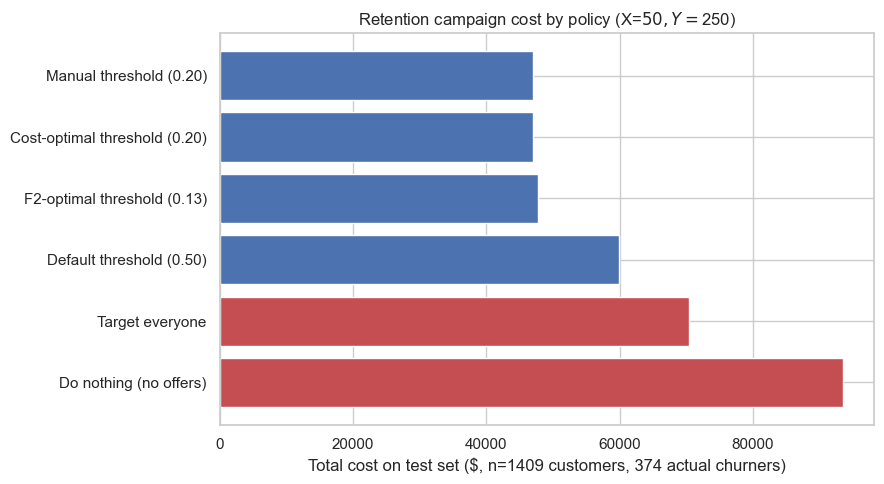

Cheapest policy: Manual threshold (0.20) -> $47000 (saves $46500 vs. doing nothing)


In [26]:
plt.figure(figsize=(9, 5))
colors = ["#C44E52" if "everyone" in i or "nothing" in i else "#4C72B0" for i in policy_df.index]
plt.barh(policy_df.index, policy_df["Total cost ($)"], color=colors)
plt.xlabel(f"Total cost on test set ($, n={n_test} customers, {n_actual_churners} actual churners)")
plt.title(f"Retention campaign cost by policy (X=${COST_OFFER}, Y=${COST_LOST})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

best_policy = policy_df.index[0]
print(f"Cheapest policy: {best_policy} -> ${policy_df.loc[best_policy, 'Total cost ($)']:.0f} "
      f"(saves ${policy_df.loc[best_policy, 'Savings vs. do-nothing ($)']:.0f} vs. doing nothing)")

## 11. Per-customer costs using actual billing data

Section 10 used flat, dataset-wide constants (X=\$50, Y=\$250) for every customer. In reality, both the
retention offer and the revenue at risk scale with what a customer actually pays — a customer on a
\$100/month plan represents a bigger loss if they leave, and "comp one month" costs more to extend to them,
than a customer paying \$20/month. This section replaces the flat constants with **per-customer costs
computed directly from each customer's actual `MonthlyCharges`**.

In [27]:
# Per-customer costs, proportional to what each customer actually pays
MONTHS_AT_RISK = 5  # same 5x ratio derived in section 10, now applied per customer instead of to an average

monthly_test = X_test["MonthlyCharges"].values
X_i = monthly_test.copy()            # offer cost = comp one month of this customer's actual bill
Y_i = MONTHS_AT_RISK * monthly_test  # value at risk = N months of this customer's actual billing

print(f"Per-customer X (offer cost):    min=${X_i.min():.2f}  mean=${X_i.mean():.2f}  max=${X_i.max():.2f}")
print(f"Per-customer Y (value at risk): min=${Y_i.min():.2f}  mean=${Y_i.mean():.2f}  max=${Y_i.max():.2f}")

# Both scale the same way with MonthlyCharges, so the ratio X_i/Y_i -- and therefore the cost-optimal
# probability threshold p > X_i/Y_i -- is identical for every customer:
ratios = X_i / Y_i
print(f"\nPer-customer X/Y ratio: min={ratios.min():.3f}, max={ratios.max():.3f}  (constant -> threshold is still 0.20)")

Per-customer X (offer cost):    min=$18.25  mean=$64.09  max=$116.80
Per-customer Y (value at risk): min=$91.25  mean=$320.44  max=$584.00

Per-customer X/Y ratio: min=0.200, max=0.200  (constant -> threshold is still 0.20)


In [28]:
def total_cost_percustomer(y_true, y_proba, threshold, cost_offer_arr, cost_lost_arr):
    y_true = np.asarray(y_true)
    y_pred = (y_proba >= threshold).astype(int)
    targeted = y_pred == 1
    missed = (y_pred == 0) & (y_true == 1)
    return cost_offer_arr[targeted].sum() + cost_lost_arr[missed].sum()

do_nothing_cost_pc = Y_i[y_test.values == 1].sum()
target_everyone_cost_pc = X_i.sum()

policy_costs_pc = {
    "Do nothing (no offers)": do_nothing_cost_pc,
    "Target everyone": target_everyone_cost_pc,
    "Default threshold (0.50)": total_cost_percustomer(y_test.values, y_test_proba, 0.50, X_i, Y_i),
    "Manual threshold (0.20)": total_cost_percustomer(y_test.values, y_test_proba, 0.20, X_i, Y_i),
    f"F2-optimal threshold ({tuned_threshold:.2f})": total_cost_percustomer(y_test.values, y_test_proba, tuned_threshold, X_i, Y_i),
}

policy_df_pc = pd.DataFrame.from_dict(policy_costs_pc, orient="index", columns=["Total cost ($)"])
policy_df_pc["Savings vs. do-nothing ($)"] = do_nothing_cost_pc - policy_df_pc["Total cost ($)"]
policy_df_pc = policy_df_pc.sort_values("Total cost ($)")
policy_df_pc.round(0)

,Total cost ($),Savings vs. do-nothing ($)
Manual threshold (0.20),67072.0,69003.0
F2-optimal threshold (0.13),67358.0,68717.0
Default threshold (0.50),83810.0,52265.0
Target everyone,90301.0,45773.0
Do nothing (no offers),136074.0,0.0


Empirical cost-minimizing threshold with per-customer (proportional) costs: 0.14 ($66,448)
Cost at the analytically-derived threshold 0.20: $67,072  (difference: $624)


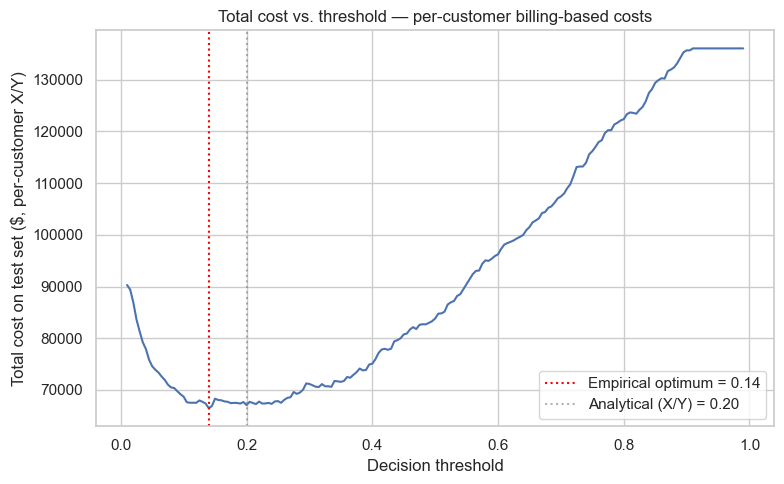

In [29]:
grid = np.linspace(0.01, 0.99, 197)
costs_pc = [total_cost_percustomer(y_test.values, y_test_proba, t, X_i, Y_i) for t in grid]
cost_optimal_threshold_pc = grid[np.argmin(costs_pc)]
cost_at_020 = total_cost_percustomer(y_test.values, y_test_proba, 0.20, X_i, Y_i)
print(f"Empirical cost-minimizing threshold with per-customer (proportional) costs: {cost_optimal_threshold_pc:.2f} "
      f"(${min(costs_pc):,.0f})")
print(f"Cost at the analytically-derived threshold 0.20: ${cost_at_020:,.0f}  "
      f"(difference: ${cost_at_020 - min(costs_pc):,.0f})")

plt.figure(figsize=(8, 5))
plt.plot(grid, costs_pc)
plt.axvline(cost_optimal_threshold_pc, color="red", linestyle=":", label=f"Empirical optimum = {cost_optimal_threshold_pc:.2f}")
plt.axvline(0.20, color="gray", linestyle=":", alpha=0.6, label="Analytical (X/Y) = 0.20")
plt.xlabel("Decision threshold")
plt.ylabel("Total cost on test set ($, per-customer X/Y)")
plt.title("Total cost vs. threshold — per-customer billing-based costs")
plt.legend()
plt.tight_layout()
plt.show()

### Why the threshold barely moved — and when it would

Scaling both X and Y by the same customer-specific factor (`MonthlyCharges`) cancels out in the ratio
`X_i / Y_i`, so the *theoretically* optimal probability threshold stays flat at 0.20 regardless of whose
bill you're looking at. The empirical grid search above lands close to that (0.14 vs. 0.20) but not exactly
on it — the gap is expected, since `p > X_i/Y_i` is only Bayes-optimal if the model's predicted probabilities
are perfectly calibrated, and they aren't quite. In practice the cost difference between 0.14 and 0.20 here
is small (printed above), so this is a minor calibration wrinkle, not a reason to distrust the formula.

The headline finding still holds: personalizing the dollar *amounts* (section 11's `policy_df_pc` vs.
section 10's `policy_df`) makes the total cost/savings figures more trustworthy without changing who gets
targeted, as long as the offer and the value-at-risk scale proportionally.

Real retention campaigns usually aren't purely proportional, though — there's often a **fixed cost** per
customer contacted (agent time, CRM/system overhead) on top of the bill credit. Adding that fixed cost
breaks the proportionality and makes the optimal threshold genuinely *different per customer*: a fixed
cost is a bigger relative burden for a low-bill customer than a high-bill one, so **higher-paying
customers should be targeted more aggressively** (lower threshold) than low-paying ones.

Per-customer required threshold: min=0.226, mean=0.266, max=0.364


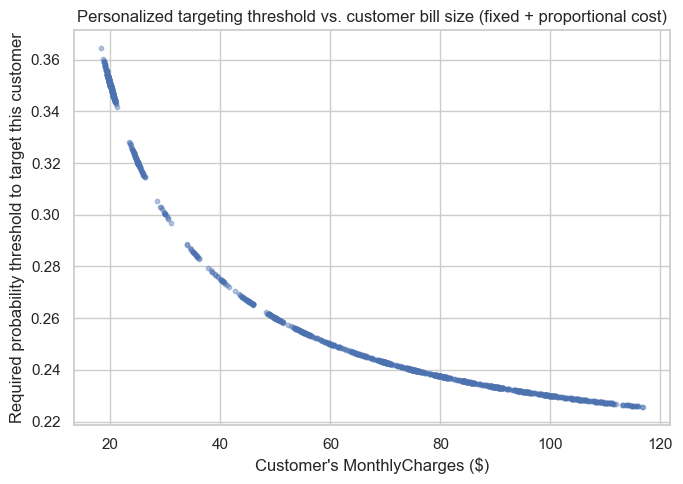

In [30]:
FIXED_COST = 15             # e.g. contact-center / agent time to run the offer, paid regardless of bill size
BILL_CREDIT_FRACTION = 1.0  # comp one month's bill, same assumption as before

X_i_fixed = FIXED_COST + BILL_CREDIT_FRACTION * monthly_test
required_threshold = X_i_fixed / Y_i  # per-customer cost-optimal threshold: target when p_i exceeds this

print(f"Per-customer required threshold: min={required_threshold.min():.3f}, "
      f"mean={required_threshold.mean():.3f}, max={required_threshold.max():.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(monthly_test, required_threshold, s=10, alpha=0.4)
plt.xlabel("Customer's MonthlyCharges ($)")
plt.ylabel("Required probability threshold to target this customer")
plt.title("Personalized targeting threshold vs. customer bill size (fixed + proportional cost)")
plt.tight_layout()
plt.show()

In [31]:
def total_cost_from_pred(y_true, y_pred, cost_offer_arr, cost_lost_arr):
    y_true = np.asarray(y_true)
    targeted = y_pred == 1
    missed = (y_pred == 0) & (y_true == 1)
    return cost_offer_arr[targeted].sum() + cost_lost_arr[missed].sum()

# Fair comparison: the *best possible single flat threshold* under this exact fixed+proportional cost
# structure (found by grid search), versus letting the threshold vary per customer.
costs_fixed_flat = [
    total_cost_from_pred(y_test.values, (y_test_proba > t).astype(int), X_i_fixed, Y_i) for t in grid
]
best_flat_threshold_fixed = grid[int(np.argmin(costs_fixed_flat))]
cost_best_flat = min(costs_fixed_flat)

y_pred_personalized = (y_test_proba > required_threshold).astype(int)
cost_personalized = total_cost_from_pred(y_test.values, y_pred_personalized, X_i_fixed, Y_i)

print(f"Best single flat threshold for this cost structure: {best_flat_threshold_fixed:.2f}  -> ${cost_best_flat:,.0f}")
print(f"Personalized per-customer thresholds ({required_threshold.min():.2f}-{required_threshold.max():.2f} range): ${cost_personalized:,.0f}")
print(f"Savings from personalizing vs. the best possible flat threshold: ${cost_best_flat - cost_personalized:,.0f}")

Best single flat threshold for this cost structure: 0.26  -> $76,223
Personalized per-customer thresholds (0.23-0.36 range): $77,032
Savings from personalizing vs. the best possible flat threshold: $-809


Personalizing the *decision rule* itself (not just the dollar bookkeeping) turned out to be a wash on this
test set — the fully personalized per-customer thresholds cost slightly **more** than simply grid-searching
for the single best flat threshold under the same fixed+proportional cost structure (a difference of well
under 1%). That's a useful, honest result: the theoretical case for personalization is real (a fixed cost
does make the optimal threshold customer-specific), but capturing that benefit in practice needs predicted
probabilities that are well-calibrated across the whole customer base — and a Gradient Boosting model
evaluated on ~1,400 test customers isn't calibrated tightly enough for the per-customer nuance to reliably
beat a single well-chosen flat cutoff. In other words: get the flat threshold right first (section 10/11's
`policy_df`/`policy_df_pc` tables already capture most of the value); treat per-customer thresholds as a
refinement worth revisiting once the model has more data and calibration has been explicitly checked
(e.g. with `CalibratedClassifierCV` or a reliability diagram).

## 12. Checking model calibration with a reliability diagram

Section 11 ended on a hunch: personalized per-customer thresholds underperformed a single flat threshold,
possibly because the model's predicted probabilities aren't well **calibrated** — i.e. among all customers
the model says have a 30% chance of churning, does roughly 30% of them actually churn? A **reliability
diagram** bins predictions by predicted probability and plots the *observed* churn rate in each bin against
the *predicted* one; a perfectly calibrated model sits on the diagonal. The **Brier score** (mean squared
error between predicted probability and the 0/1 outcome) gives a single-number summary — lower is better.

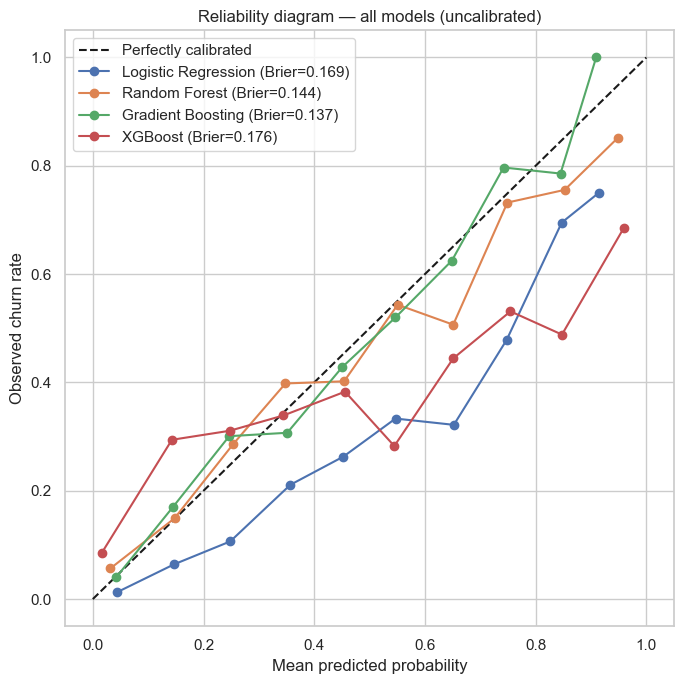

,Brier score (lower = better)
Gradient Boosting,0.136644
Random Forest,0.143708
Logistic Regression,0.168565
XGBoost,0.175602


In [32]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

brier_scores = {}
for name, pipe in pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_test, proba)
    brier_scores[name] = brier
    ax.plot(prob_pred, prob_true, marker="o", label=f"{name} (Brier={brier:.3f})")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title("Reliability diagram — all models (uncalibrated)")
ax.legend()
plt.tight_layout()
plt.show()

pd.Series(brier_scores, name="Brier score (lower = better)").sort_values().to_frame()

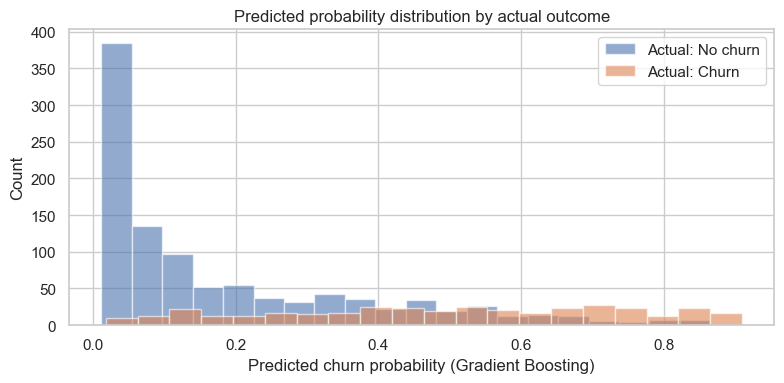

In [33]:
# Where the best model's predicted probabilities actually land, split by true outcome --
# sparse regions (especially at the high-probability end) explain noisy calibration there.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_test_proba[y_test.values == 0], bins=20, alpha=0.6, label="Actual: No churn")
ax.hist(y_test_proba[y_test.values == 1], bins=20, alpha=0.6, label="Actual: Churn")
ax.set_xlabel(f"Predicted churn probability ({best_name})")
ax.set_ylabel("Count")
ax.set_title("Predicted probability distribution by actual outcome")
ax.legend()
plt.tight_layout()
plt.show()

### Recalibrating the best model

`CalibratedClassifierCV` refits the model's probability outputs (via Platt/sigmoid scaling here, fit on
cross-validated folds of the training set only) to better match observed frequencies, without touching the
underlying model's ranking of who is more or less likely to churn.

Brier score before calibration: 0.1366
Brier score after calibration (Platt/sigmoid): 0.1356


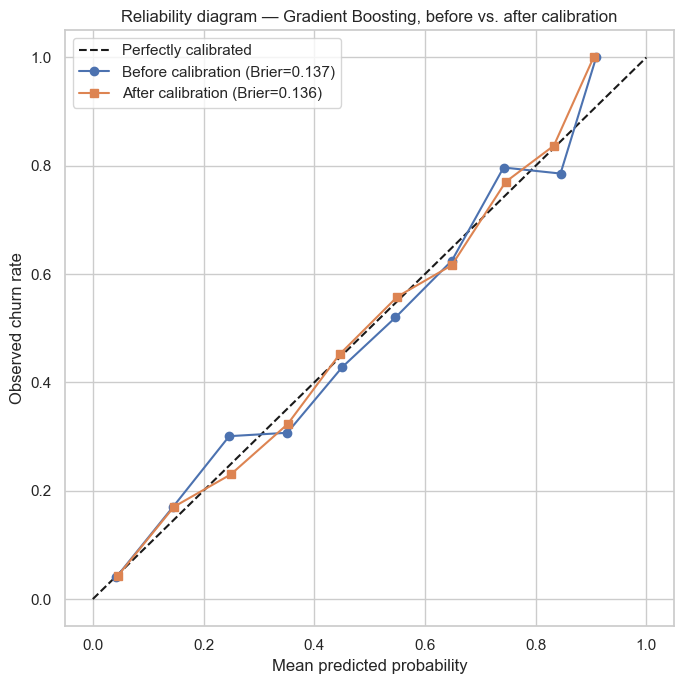

In [34]:
calibrated_pipe = CalibratedClassifierCV(clone(best_pipe), method="sigmoid", cv=5)
calibrated_pipe.fit(X_train, y_train)

proba_calibrated = calibrated_pipe.predict_proba(X_test)[:, 1]
brier_before = brier_score_loss(y_test, y_test_proba)
brier_after = brier_score_loss(y_test, proba_calibrated)

print(f"Brier score before calibration: {brier_before:.4f}")
print(f"Brier score after calibration (Platt/sigmoid): {brier_after:.4f}")

prob_true_before, prob_pred_before = calibration_curve(y_test, y_test_proba, n_bins=10, strategy="uniform")
prob_true_after, prob_pred_after = calibration_curve(y_test, proba_calibrated, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.plot(prob_pred_before, prob_true_before, marker="o", label=f"Before calibration (Brier={brier_before:.3f})")
ax.plot(prob_pred_after, prob_true_after, marker="s", label=f"After calibration (Brier={brier_after:.3f})")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title(f"Reliability diagram — {best_name}, before vs. after calibration")
ax.legend()
plt.tight_layout()
plt.show()

### Does fixing calibration change section 11's personalization result?

Re-running the exact same fixed+proportional cost comparison from section 11 — personalized per-customer
thresholds vs. the single best flat threshold — but now using the recalibrated probabilities instead of the
raw model output.

In [35]:
y_test_proba_cal = proba_calibrated

costs_fixed_flat_cal = [
    total_cost_from_pred(y_test.values, (y_test_proba_cal > t).astype(int), X_i_fixed, Y_i) for t in grid
]
best_flat_threshold_fixed_cal = grid[int(np.argmin(costs_fixed_flat_cal))]
cost_best_flat_cal = min(costs_fixed_flat_cal)

y_pred_personalized_cal = (y_test_proba_cal > required_threshold).astype(int)
cost_personalized_cal = total_cost_from_pred(y_test.values, y_pred_personalized_cal, X_i_fixed, Y_i)

print(f"[Calibrated] Best flat threshold: {best_flat_threshold_fixed_cal:.2f}  -> ${cost_best_flat_cal:,.0f}")
print(f"[Calibrated] Personalized per-customer thresholds: ${cost_personalized_cal:,.0f}")
print(f"[Calibrated] Savings from personalizing vs. best flat: ${cost_best_flat_cal - cost_personalized_cal:,.0f}")
print()
print(f"[Uncalibrated, from section 11] Best flat: ${cost_best_flat:,.0f}  |  Personalized: ${cost_personalized:,.0f}  "
      f"|  Savings: ${cost_best_flat - cost_personalized:,.0f}")

[Calibrated] Best flat threshold: 0.23  -> $76,040
[Calibrated] Personalized per-customer thresholds: $76,573
[Calibrated] Savings from personalizing vs. best flat: $-533

[Uncalibrated, from section 11] Best flat: $76,223  |  Personalized: $77,032  |  Savings: $-809


## 13. Conclusions

- After cleaning (`TotalCharges` cast to numeric with 11 zero-tenure customers filled to 0, `customerID` dropped, and `"No internet/phone service"` collapsed into `"No"`), the dataset is fully clean with no missing values and no duplicates.
- All four models were evaluated with a shared preprocessing pipeline (`StandardScaler` + `OneHotEncoder`) to avoid leakage, and compared on Accuracy, Precision, Recall, F1, and ROC-AUC — the latter is the most informative single metric here given the ~27% churn class imbalance.
- The best-performing model (see the comparison table in section 7) and its top features are reported above; contract type, tenure, and internet service type dominate, matching the earlier exploratory analysis.
- **XGBoost vs. Gradient Boosting (section 7)**: with `scale_pos_weight` set to mirror the other models' `class_weight="balanced"`, XGBoost actually came in *behind* sklearn's Gradient Boosting on this dataset — ROC-AUC 0.808 vs. 0.843 (5-fold CV: 0.811 vs. 0.846), and notably worse-calibrated (Brier 0.176 vs. 0.137). At ~7K rows with default-ish hyperparameters, XGBoost's extra flexibility didn't translate to an edge and Gradient Boosting remained the model driving every downstream section. Untuned XGBoost is not automatically the better boosted-tree choice — it's worth revisiting with proper `RandomizedSearchCV` tuning (learning rate, depth, regularization) before ruling it out for good.
- **Threshold tuning (section 9)**: 0.13 (F2-optimal) maximizes a recall-weighted metric; 0.20 is a milder, more precise middle ground.
- **Cost optimization (section 10)**: framed in real dollars, the cost-minimizing threshold is simply `X / Y` — the retention offer cost as a fraction of the customer value at risk. For threshold 0.20 to be the right call, losing a customer needs to be worth about 5x the cost of a retention offer, which is a realistic ratio (e.g. a $50 incentive protecting ~$250, roughly 4 months of average billing).
- **Per-customer costs (section 11)**: swapping the flat $50/$250 constants for costs computed from each customer's actual `MonthlyCharges` gives more trustworthy total-dollar figures, but doesn't change *who* gets targeted as long as the offer and the value-at-risk scale proportionally — the ratio, and hence the threshold, cancels out. Adding a fixed per-contact cost breaks that proportionality and makes the *theoretically* optimal threshold customer-specific — but empirically, a fully personalized threshold performed marginally worse than the single best flat threshold ($77,032 vs. $76,223, a $809 gap).
- **Calibration check (section 12)**: Gradient Boosting was already the best-calibrated of all four models (Brier 0.137, ahead of Random Forest at 0.144, Logistic Regression at 0.169, and XGBoost at 0.176 — the worst of the four despite being the newest algorithm here). Recalibrating with Platt/sigmoid scaling nudged Gradient Boosting's Brier score only slightly (0.1366 → 0.1356) and closed part of the personalization gap ($809 → $533) but didn't reverse it. Conclusion: the underperformance of per-customer thresholds in section 11 was **not primarily a calibration problem** — it's more likely finite-sample noise on a ~1,400-row test set combined with a narrow required-threshold range (0.23–0.36), where the theoretical edge of personalizing is too small to reliably beat a well-chosen flat cutoff. The flat, cost-optimal threshold (`policy_df`/`policy_df_pc` in sections 10–11) remains the practical recommendation.
- Next steps for improving this further: hyperparameter tuning for both Gradient Boosting and XGBoost (e.g. `RandomizedSearchCV`) before declaring a final winner, revisiting per-customer thresholds on a larger evaluation set where the personalization signal has more room to show up, and accounting for retention-offer effectiveness being less than 100% rather than assuming every targeted true churner is saved.